In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from simulations.benchmarks.hf import hf
from simulations.benchmarks.ethene import ethene
from simulations.molecules import MoleculeSimulator
from solvers.evc_solver import EVCSolver

In [11]:
from src.utils.procrustes_utils import (
    compute_procrustes_matrices,
    compute_cc_with_procrustes
)
from src.utils.matrix_utils import orthonormalize_ts
from src.utils.gpy_utils import get_model_gpy

## Simulator

In [12]:
ethene_simulator = MoleculeSimulator(
    molecule_fun=ethene,
    basis="cc-pVTZ",
    coord_scale=0.1,
    verbose=0,
)

### Reference molecule

In [13]:
include_kwargs = {
    "include_geometries": True,
    "include_integrals": True,
    "include_hartree_fock": True,
    "include_cc": False,
    "include_coordinates": False,
    "include_all": False
}

In [14]:
ethene_reference = ethene_simulator.simulate(
    molecule_kwargs={
        "cc_bond_distance": 1.0,
        "perturb": False
    },
    **include_kwargs
)

In [15]:
print(ethene_reference["atoms"])
print(ethene_reference["positions"])
for k, v in ethene_reference.items():
    print(k, v.shape)

['C' 'C' 'H' 'H' 'H' 'H']
[[ 0.          0.          0.        ]
 [ 1.          0.          0.        ]
 [ 0.56367826  0.92708784  0.        ]
 [ 0.56367826 -0.92708784  0.        ]
 [ 0.43632177  0.92708784  0.        ]
 [ 0.43632177 -0.92708784  0.        ]]
atoms (6,)
positions (6, 3)
nuc_attraction (116, 116)
overlaps (116, 116)
occupancies (116,)
determinant (116, 116)
hf_energy ()


(116, 116)


<Axes: >

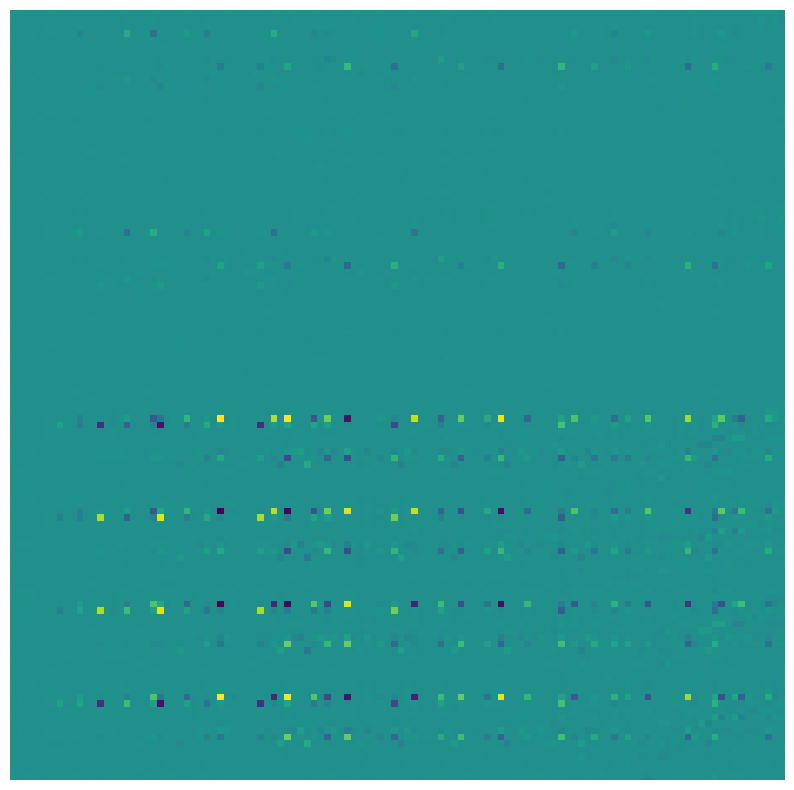

In [16]:
reference_determinant = ethene_reference["determinant"]
print(reference_determinant.shape)

f, ax = plt.subplots(1, figsize=(10, 10))
sns.heatmap(reference_determinant, cbar=False, xticklabels=False, yticklabels=False, cmap="viridis")

(116, 116)


<Axes: >

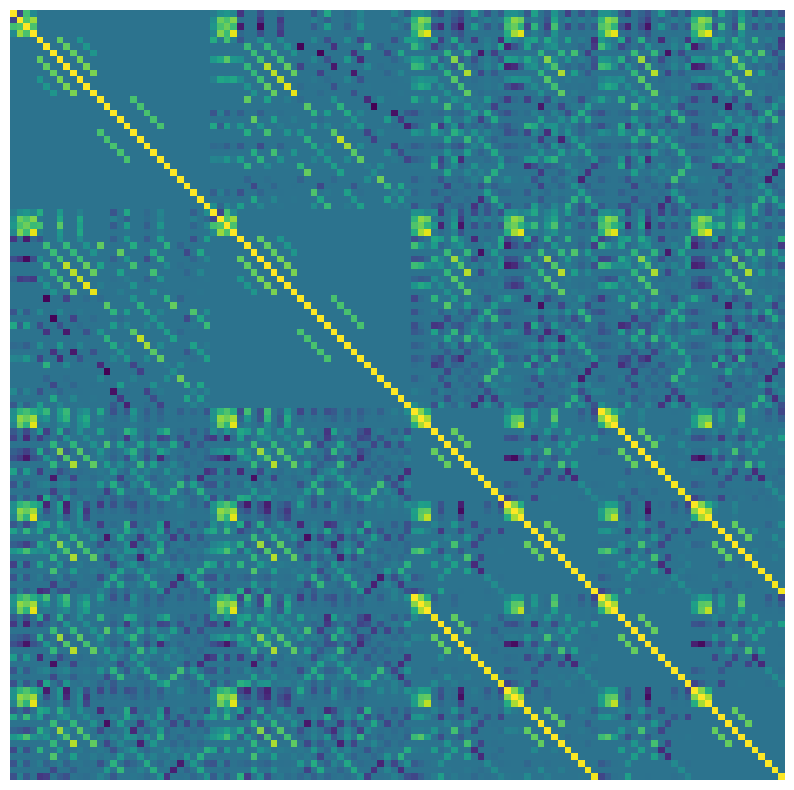

In [17]:
reference_overlap = ethene_reference["overlaps"]
print(reference_overlap.shape)

f, ax = plt.subplots(1, figsize=(10, 10))
sns.heatmap(reference_overlap, cbar=False, xticklabels=False, yticklabels=False, cmap="viridis")

### Sample and target molecules

In [18]:
target_molecules = ethene_simulator.sample(10, include_kwargs={"include_geometries": True})

Generating samples: 100%|██████████| 10/10 [00:00<00:00, 831.72it/s]


In [19]:
for k, v in target_molecules.items():
    print(f"{k}: {v.shape}")

atoms: (10, 6)
positions: (10, 6, 3)


In [20]:
target_procrustes_matrices = compute_procrustes_matrices(
    batched_atoms=target_molecules["atoms"],
    batched_positions=target_molecules["positions"],
    reference_determinant=reference_determinant,
    reference_overlap=reference_overlap,
)

Computing procrustes: 100%|██████████| 10/10 [00:16<00:00,  1.62s/it]


In [21]:
for k, v in target_procrustes_matrices.items():
    print(f"{k}: {v.shape}")

rotation_matrices: (10, 116, 116)
procrustes_orbitals: (10, 116, 116)


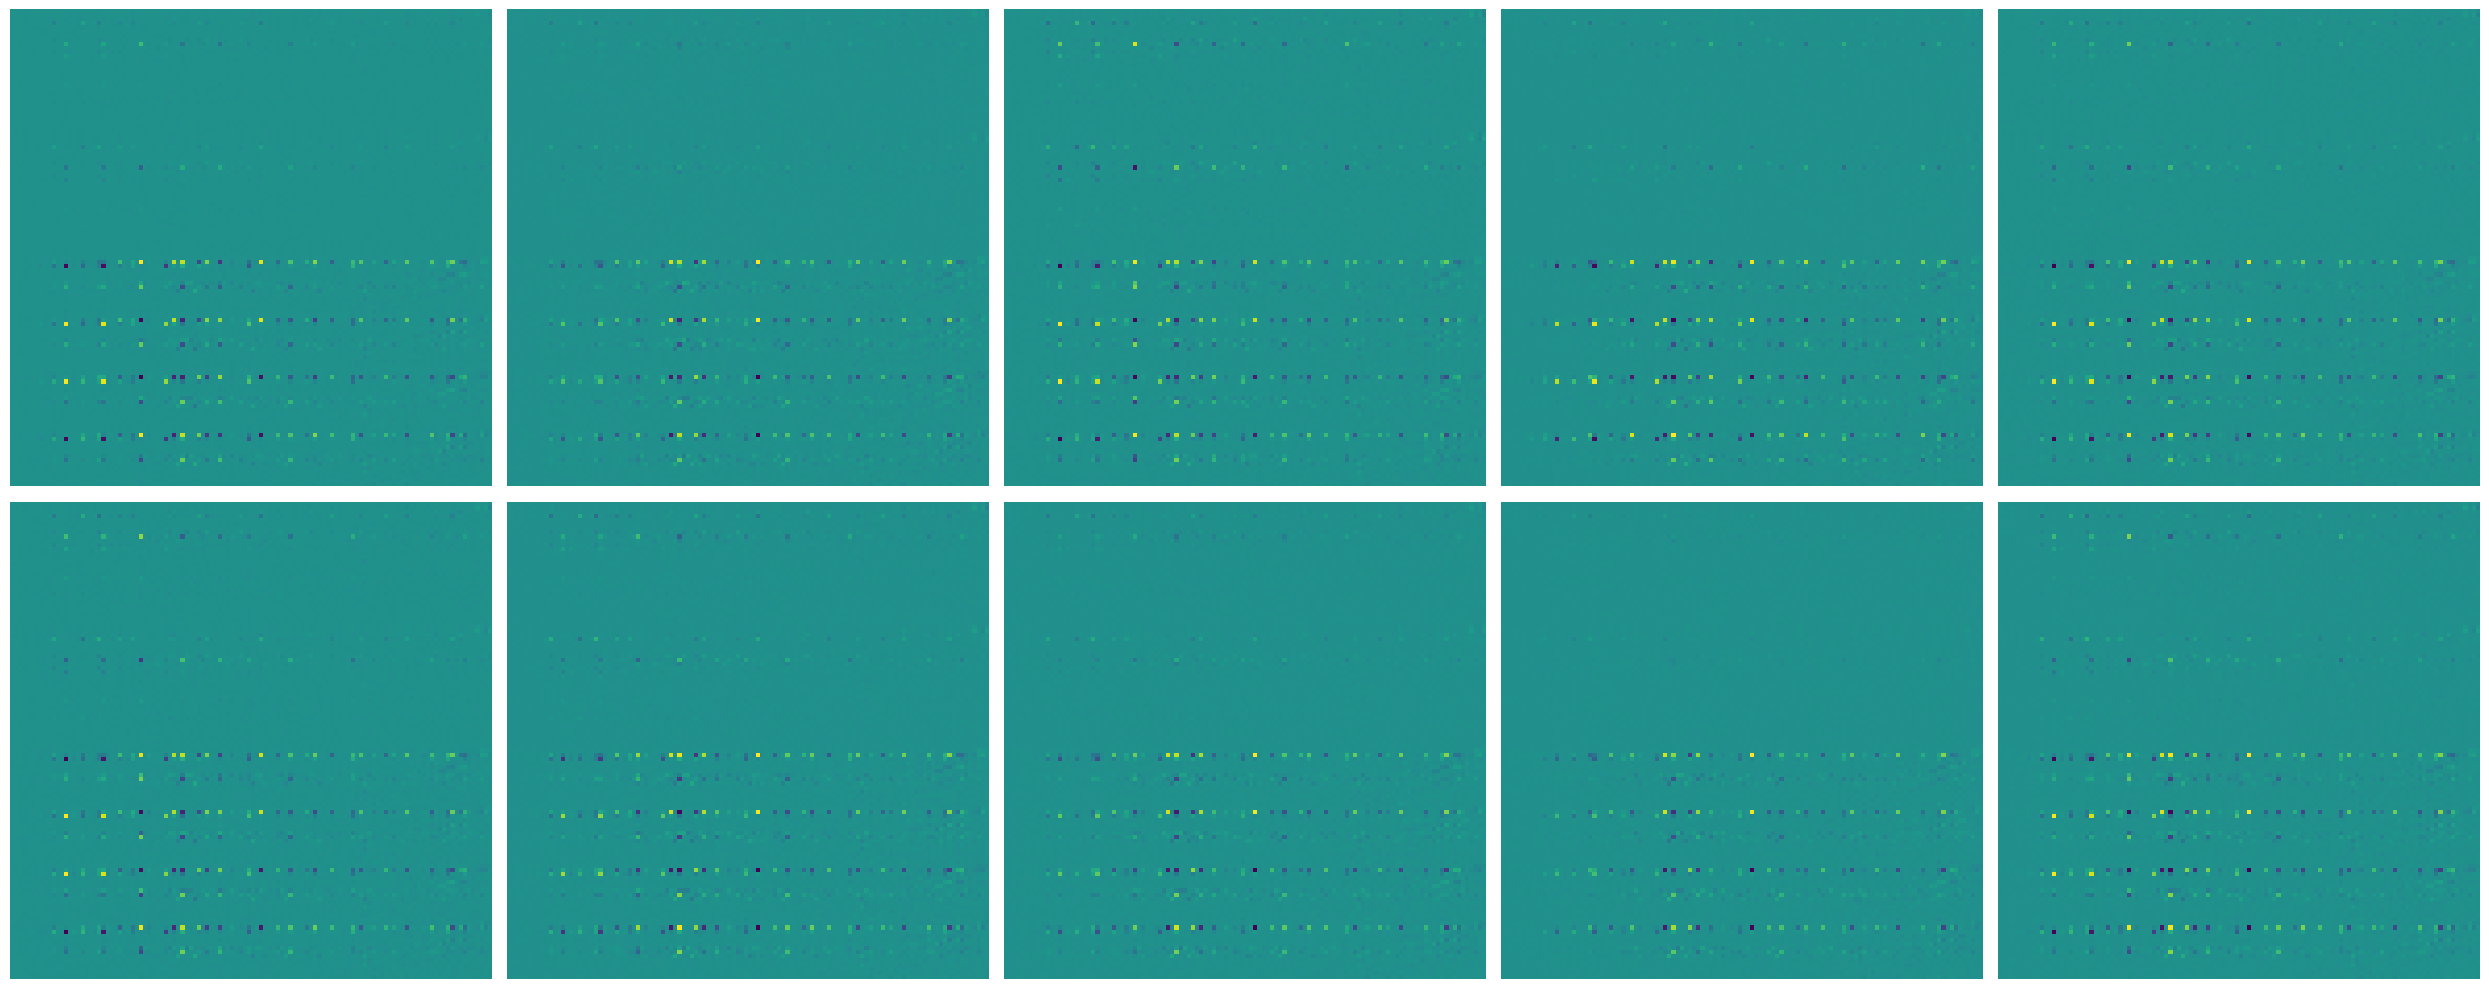

In [22]:
f, axes = plt.subplots(2, 5, figsize=(25, 10))

for i, ax in enumerate(axes.flatten()):
    sns.heatmap(target_procrustes_matrices["procrustes_orbitals"][i], cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, ax=ax)

plt.tight_layout()

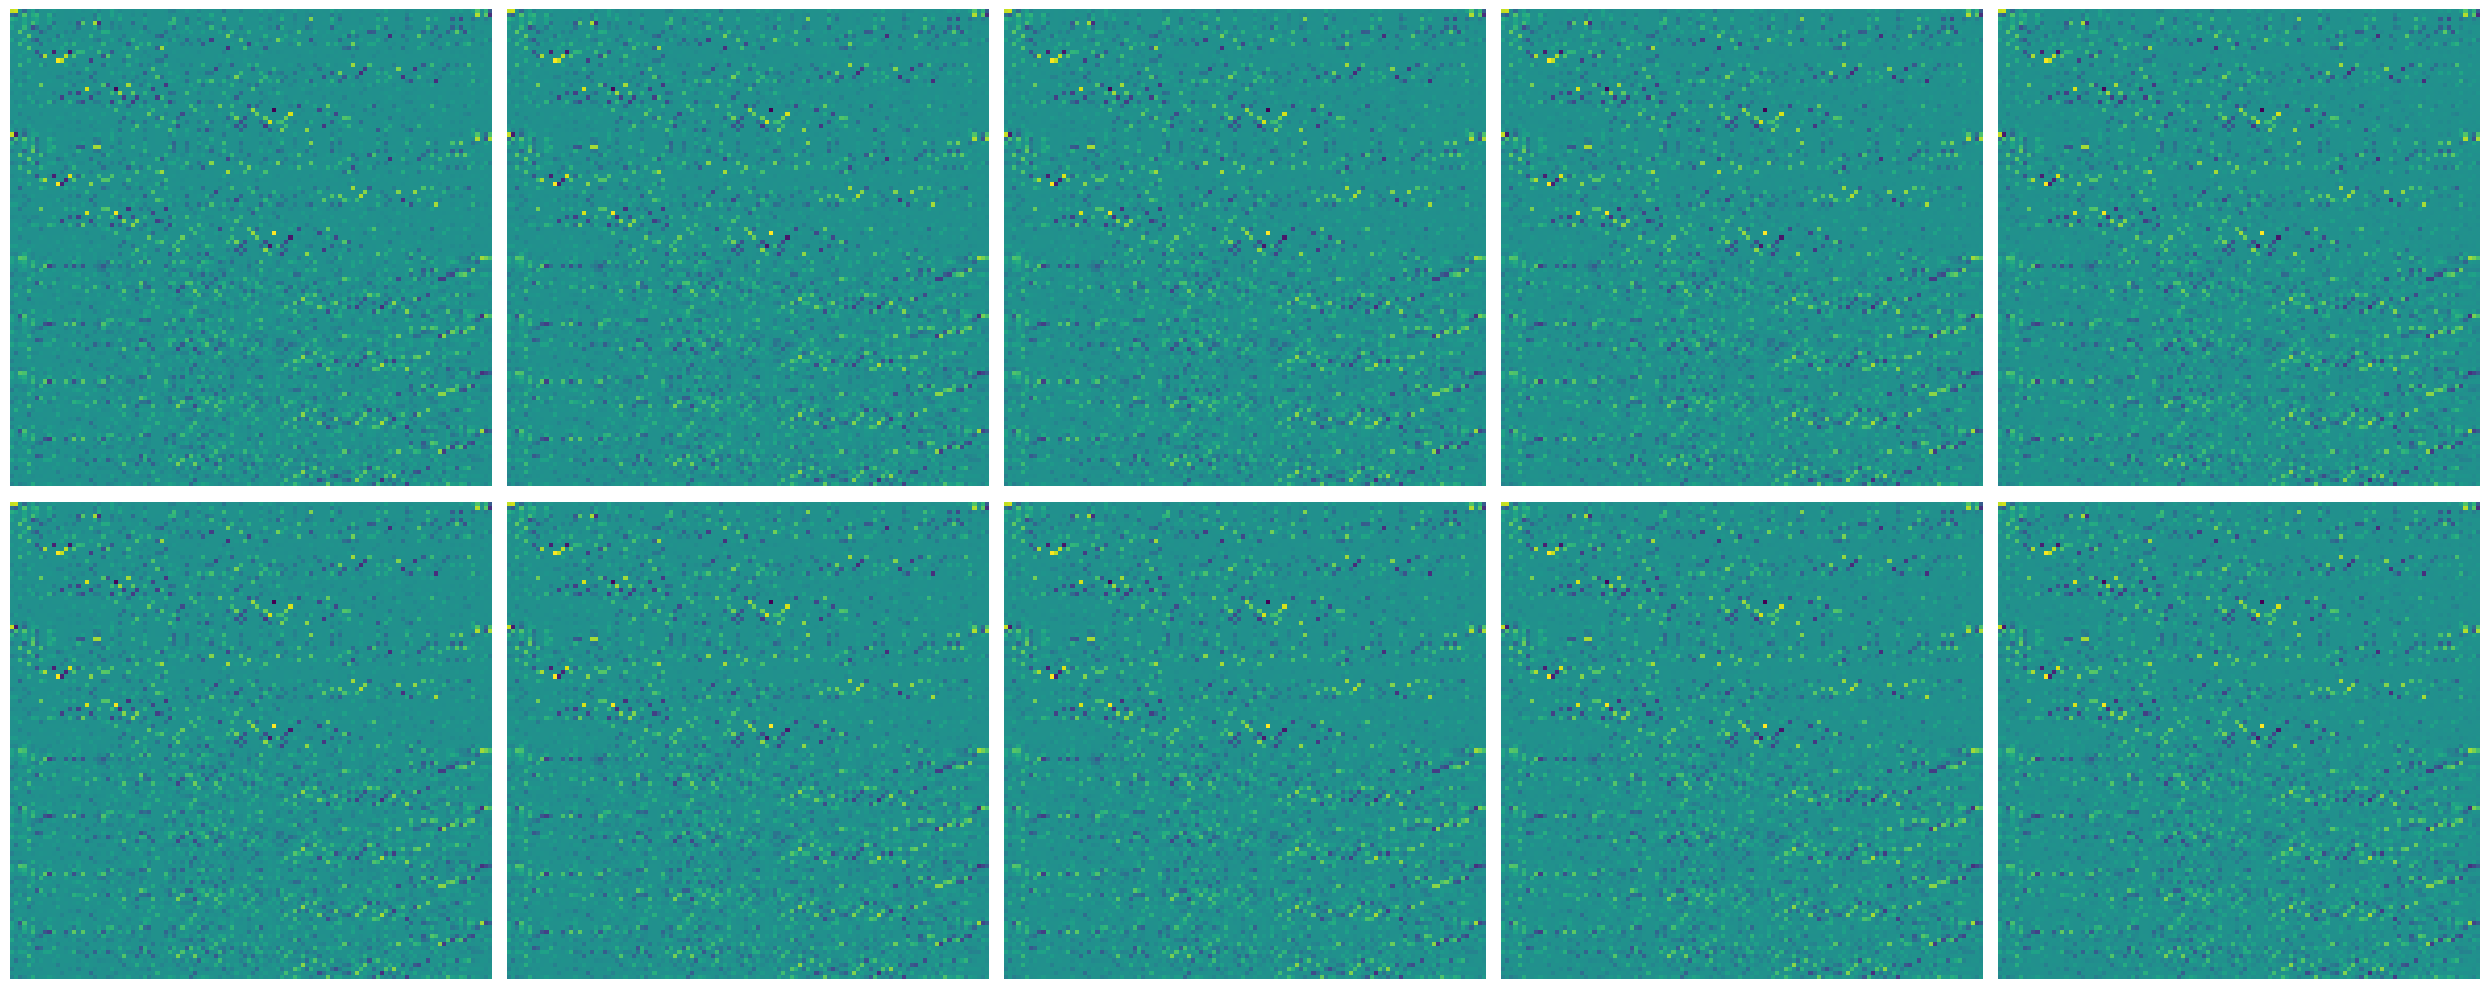

In [23]:
f, axes = plt.subplots(2, 5, figsize=(25, 10))

for i, ax in enumerate(axes.flat):
    sns.heatmap(target_procrustes_matrices["rotation_matrices"][i], cmap="viridis", cbar=False, xticklabels=False, yticklabels=False, ax=ax)

plt.tight_layout()

In [24]:
sample_molecules = ethene_simulator.sample(81, include_kwargs={"include_geometries": True})

Generating samples: 100%|██████████| 81/81 [00:00<00:00, 872.77it/s]


In [25]:
sample_procrustes_matrices = compute_procrustes_matrices(
    batched_atoms=sample_molecules["atoms"],
    batched_positions=sample_molecules["positions"],
    reference_determinant=reference_determinant,
    reference_overlap=reference_overlap,
)

Computing procrustes: 100%|██████████| 81/81 [03:24<00:00,  2.52s/it]


In [27]:
procrustes_cc = compute_cc_with_procrustes(
    batched_atoms=sample_molecules["atoms"],
    batched_positions=sample_molecules["positions"],
    reference_determinant=reference_determinant,
    reference_overlap=reference_overlap,
)

Computing CCSD: 100%|██████████| 81/81 [12:57<00:00,  9.60s/it]


In [62]:
procrustes_cc.keys()

dict_keys(['t1', 't2', 'ccsd_energy'])

In [63]:
for k, v in procrustes_cc.items():
    print(f"{k}: {v.shape}")

t1: (81, 8, 108)
t2: (81, 8, 8, 108, 108)
ccsd_energy: (81,)


In [64]:
evc_solver = EVCSolver(
    geometries=sample_molecules,
    t1s=procrustes_cc["t1"],
    t2s=procrustes_cc["t2"],
    reference_determinant=reference_determinant,
    reference_overlap=reference_overlap
)

In [65]:
orthogonalized_ts = orthonormalize_ts(t1s=evc_solver.t1s, t2s=evc_solver.t2s, lowdin=True)

In [66]:
for k, v in orthogonalized_ts.items():
    print(f"{k}: {v.shape}")

t1: (81, 8, 108)
t2: (81, 8, 8, 108, 108)
coefficients: (81, 81)


In [67]:
orthogonalized_ts["t2"][0].reshape(-1).shape

(746496,)

In [69]:
t1_ml = []
t2_ml = []
params_ml = []
predictions = []

In [73]:
num_target_molecules = target_molecules["atoms"].shape[0]
num_sample_molecules = sample_molecules["atoms"].shape[0]
print(num_target_molecules, num_sample_molecules)

10 81


In [85]:
stds_gpy = np.zeros(num_target_molecules) # This should be 10

In [89]:
for i in range(num_sample_molecules): # This should be 81
    mean, std, params = get_model_gpy(
        U_list = sample_procrustes_matrices["rotation_matrices"],
        U_list_target=target_procrustes_matrices["rotation_matrices"],
        y=orthogonalized_ts["coefficients"][i] - np.mean(orthogonalized_ts["coefficients"][i])
    )
    predictions.append(mean + np.mean(orthogonalized_ts["coefficients"][i]))
    stds_gpy += (std)
    params_ml.append(params)

TypeError: Parameterized.__init__() got an unexpected keyword argument 'input_dim'